In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [2]:
raw_data = pd.read_csv('avsurvey2019data.csv')
data = raw_data.copy()
data.head()

,RespondentID,StartDate,EndDate,FamiliarityNews,FamiliarityTech,SharedCyclist,SharedPedestrian,SafeAv,SafeHuman,AvImpact,ProvingGround,Speed25Mph,TwoEmployeesAv,SchoolZoneManual,ShareTripData,SharePerformanceData,ReportSafetyIncident,ArizonaCrash,ZipCode,BikePghMember,AutoOwner,SmartphoneOwner,Age
0,10505419886,2/2/2019,2/2/2019,To a moderate extent,Somewhat familiar,Yes,Yes,4.0,2.0,Significantly Better,Approve,No,Not sure,No,Not sure,Yes,Yes,No change,15212,No,Yes,Yes,25-34
1,10505138734,2/2/2019,2/2/2019,To a moderate extent,Somewhat familiar,Yes,No,5.0,4.0,Significantly Better,Neutral,No,No,No,No,Yes,Not sure,No change,15232,Not sure,Yes,Yes,25-34
2,10504803283,2/1/2019,2/1/2019,To a moderate extent,Somewhat familiar,Yes,Yes,1.0,4.0,Significantly Worse,Disapprove,Not sure,Yes,No,No,No,Not sure,Significantly more negative opinion,NaN,No,No,No,NaN
3,10504337177,2/1/2019,2/1/2019,To a moderate extent,Extremely familiar,Yes,Yes,2.0,3.0,Slightly Worse,Disapprove,Yes,Yes,Yes,No,Yes,Yes,No change,15136,No,No,Yes,55-64
4,10504261546,2/1/2019,2/1/2019,To a moderate extent,Mostly familiar,Yes,No,5.0,3.0,Slightly Better,Neutral,No,No,Not sure,Yes,Yes,No,No change,15201,Yes,No,Yes,35-44


In [3]:
data.describe(include = 'all')

,RespondentID,StartDate,EndDate,FamiliarityNews,FamiliarityTech,SharedCyclist,SharedPedestrian,SafeAv,SafeHuman,AvImpact,ProvingGround,Speed25Mph,TwoEmployeesAv,SchoolZoneManual,ShareTripData,SharePerformanceData,ReportSafetyIncident,ArizonaCrash,ZipCode,BikePghMember,AutoOwner,SmartphoneOwner,Age
count,7.950000e+02,795,795,794,794,792,793,787.000000,792.000000,788,792,792,792,793,793,791,794,792,763,787,792,791,788
unique,NaN,19,19,5,4,3,3,NaN,NaN,5,5,3,3,3,3,3,3,5,121,3,2,2,7
top,NaN,1/16/2019,1/16/2019,To a moderate extent,Somewhat familiar,Yes,Yes,NaN,NaN,Significantly Better,Approve,Yes,No,Yes,Yes,Yes,Yes,No change,15217,Yes,Yes,Yes,25-34
freq,NaN,443,442,293,306,422,481,NaN,NaN,303,381,303,318,396,591,673,673,478,82,387,748,760,205
mean,1.047672e+10,NaN,NaN,NaN,NaN,NaN,NaN,3.679797,2.729798,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,9.586209e+06,NaN,NaN,NaN,NaN,NaN,NaN,1.192272,0.901030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.046856e+10,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.047125e+10,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.047189e+10,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.047697e+10,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
data['Age'].isnull().sum()

7

In [5]:
data['Age'].unique()

array(['25-34', nan, '55-64', '35-44', '45-54', 'Under 18', '65+',
       '18-24'], dtype=object)

In [6]:
data = data.dropna(subset = ['Age'])
data = data.dropna(subset = ['SafeAv'])
data = data.dropna(subset = ['SafeHuman'])
data.isnull().sum()

RespondentID             0
StartDate                0
EndDate                  0
FamiliarityNews          1
FamiliarityTech          0
SharedCyclist            3
SharedPedestrian         1
SafeAv                   0
SafeHuman                0
AvImpact                 5
ProvingGround            2
Speed25Mph               2
TwoEmployeesAv           2
SchoolZoneManual         1
ShareTripData            0
SharePerformanceData     2
ReportSafetyIncident     0
ArizonaCrash             3
ZipCode                 27
BikePghMember            7
AutoOwner                2
SmartphoneOwner          1
Age                      0
dtype: int64

In [7]:
data['Age'] = data['Age'].map({'Under 18': 0, '18-24': 1, '25-34': 2, '35-44': 3, '45-54': 4, '55-64': 5, '65+': 6})

In [8]:
values_age, counts_age = np.unique(data['Age'], return_counts = True)

[Text(0, 0, '1'),
 Text(0, 0, '33'),
 Text(0, 0, '205'),
 Text(0, 0, '174'),
 Text(0, 0, '127'),
 Text(0, 0, '144'),
 Text(0, 0, '94')]

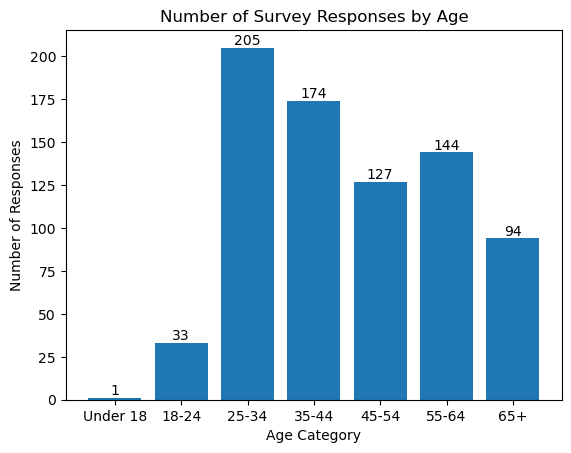

In [9]:
fig, ax = plt.subplots()
bar_container = ax.bar(values_age, counts_age)
ax.set(xlabel = 'Age Category', ylabel = 'Number of Responses', title = 'Number of Survey Responses by Age')
ax.set_xticks(values_age)
ax.set_xticklabels(['Under 18','18-24','25-34','35-44','45-54','55-64','65+'])
ax.bar_label(bar_container)

In [10]:
values_av, counts_av = np.unique(data['SafeAv'], return_counts = True)

[Text(0, 0, '56'),
 Text(0, 0, '65'),
 Text(0, 0, '177'),
 Text(0, 0, '246'),
 Text(0, 0, '234')]

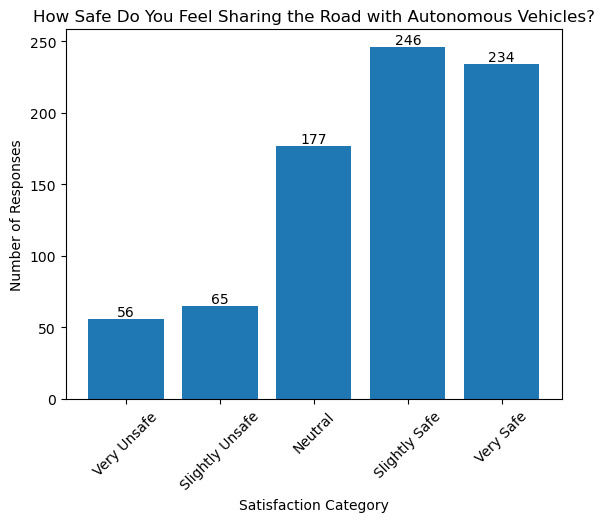

In [11]:
fig, ax = plt.subplots()
bar_container = ax.bar(values_av, counts_av)
ax.set(xlabel = 'Satisfaction Category', ylabel = 'Number of Responses', title = 'How Safe Do You Feel Sharing the Road with Autonomous Vehicles?')
ax.set_xticks(values_av)
ax.set_xticklabels(['Very Unsafe','Slightly Unsafe','Neutral','Slightly Safe','Very Safe'])
ax.tick_params(axis = 'x', rotation = 45)
ax.bar_label(bar_container)

In [12]:
values_human, counts_human = np.unique(data['SafeHuman'], return_counts = True)

[Text(0, 0, '69'),
 Text(0, 0, '228'),
 Text(0, 0, '349'),
 Text(0, 0, '114'),
 Text(0, 0, '18')]

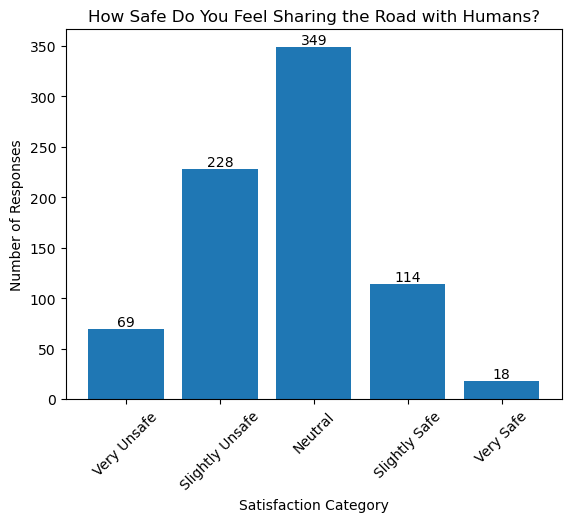

In [13]:
fig, ax = plt.subplots()
bar_container = ax.bar(values_human, counts_human)
ax.set(xlabel = 'Satisfaction Category', ylabel = 'Number of Responses', title = 'How Safe Do You Feel Sharing the Road with Humans?')
ax.set_xticks(values_human)
ax.set_xticklabels(['Very Unsafe','Slightly Unsafe','Neutral','Slightly Safe','Very Safe'])
ax.tick_params(axis = 'x', rotation = 45)
ax.bar_label(bar_container)

In [14]:
new_data = data[['SafeAv','SafeHuman','Age']]
new_data

,SafeAv,SafeHuman,Age
0,4.0,2.0,2
1,5.0,4.0,2
3,2.0,3.0,5
4,5.0,3.0,3
5,1.0,3.0,3
...,...,...,...
790,4.0,2.0,4
791,4.0,2.0,3
792,4.0,4.0,3
793,5.0,1.0,5


In [15]:
new_data['SafeAv'].mean()

3.690231362467866

In [16]:
new_data['SafeHuman'].mean()

2.7223650385604112

In [17]:
means = (new_data.groupby('Age')[['SafeAv', 'SafeHuman']]
         .mean()
         .reset_index())
print(means)

   Age    SafeAv  SafeHuman
0    0  4.000000   3.000000
1    1  4.090909   2.757576
2    2  3.785366   2.595122
3    3  3.747126   2.695402
4    4  3.606299   2.700787
5    5  3.486111   2.826389
6    6  3.659574   2.904255


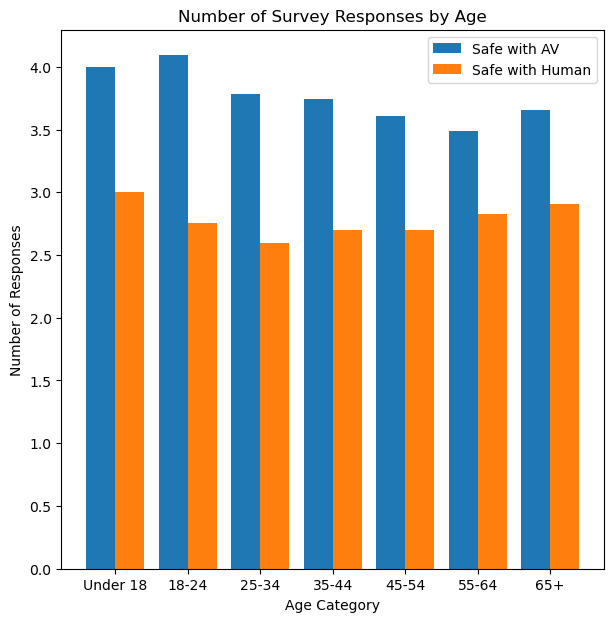

In [18]:
fig, ax = plt.subplots(figsize = (7,7))
w, x = 0.4, np.arange(len(values_age))
bar_container = ax.bar(x - w/2, means['SafeAv'], width = w, label = 'Safe with AV')
bar_container2 = ax.bar(x + w/2, means['SafeHuman'], width = w, label = 'Safe with Human')
ax.set(xlabel = 'Age Category', ylabel = 'Number of Responses', title = 'Number of Survey Responses by Age')
ax.set_xticks(values_age)
ax.set_xticklabels(['Under 18','18-24','25-34','35-44','45-54','55-64','65+'])
ax.legend()
plt.show()